#QUANTCONNECT GOVERNANCE AGENT


---

##0.REFERENCE

https://chatgpt.com/share/69c315b6-c6f8-8012-ab69-077d5d497b0d

##1.CONTEXT

**Introduction**

This notebook is designed to solve a very practical problem that many financial professionals now face when they begin working with algorithmic trading code, external research pipelines, and large language models. In many organizations, strategy code exists in one technical environment, evaluation frameworks exist in another, and governance expectations exist somewhere else entirely. The result is fragmentation. A researcher may have a strategy written in QuantConnect. A technical reviewer may want to test how that strategy behaves under synthetic scenarios. A risk or governance reviewer may want to know whether the logic is clear, whether the model is actually doing anything, and whether the evaluation process leaves behind a proper audit trail. These are all reasonable demands, but in practice they are rarely brought together into one clean workflow. This notebook is meant to do exactly that.

At a high level, the notebook receives QuantConnect code as its input and produces an evaluation package as its output. That sounds simple, but a great deal is happening in between. The notebook first establishes a controlled environment, then ingests the source strategy, then asks a language model to convert the strategy into a pure Python form that can run inside the notebook. Once that conversion has taken place, the notebook generates synthetic market data so that the converted strategy can be exercised across several distinct market conditions. It then performs a simplified backtest, analyzes the results, generates governance flags, and finally asks an evaluation agent to write a committee-style assessment. The final output is not merely a score or a chart. It is a governed audit bundle containing manifests, logs, scenario results, and a written evaluation.

For financial professionals, the most important idea is that this is not a notebook for proving that a strategy is good. It is a notebook for establishing a disciplined process of review. That distinction matters. In finance, especially in institutional settings, the quality of a process is often just as important as the quality of a result. A strong backtest with weak controls is dangerous. A strategy that appears profitable but cannot be explained, audited, or replicated will not stand up well under governance. This notebook therefore treats evaluation as a structured discipline. It is not satisfied with merely producing synthetic returns. It also records what happened, how it happened, and whether the conclusions should be treated as reliable, uncertain, or provisional.

One of the most important lessons behind this notebook is that code translation is itself a source of model risk. QuantConnect strategies are written in a framework-specific style. They rely on lifecycle methods, data structures, and execution assumptions that do not exist in plain Python. If one wants to test such a strategy in a notebook, one must first translate it. That translation can be helpful, but it can also be misleading. A language model may infer missing pieces, simplify ambiguous logic, or create conservative placeholders when the source code does not provide enough information. This means that the converted Python strategy is not automatically equivalent to the original QuantConnect strategy. The notebook therefore treats conversion as an explicit stage requiring metadata, warnings, and confidence judgments. This is not a cosmetic detail. It is a governance necessity.

Another important idea is that synthetic data is not a substitute for real market validation, but it is still useful. Financial professionals are often rightly skeptical of synthetic data because it can feel artificial. That skepticism is healthy. Synthetic data does not tell us whether a strategy truly works in live markets. What it can do, however, is reveal whether a strategy behaves coherently, whether it responds to different conditions, whether it trades at all, and whether it appears robust or fragile under controlled stress. In that sense, synthetic data serves as a laboratory environment. It helps answer preliminary questions before more expensive or operationally complex validation is attempted. A strategy that fails basic synthetic testing, or one that produces nonsensical results, should not be trusted merely because it came from a prestigious platform or a sophisticated developer.

This notebook also addresses an issue that is often underestimated in algorithmic trading review: silent failure. A strategy can appear technically healthy while doing nothing of substance. It may run without crashing, produce neat charts, and leave behind a clean log, yet still never take positions, never change exposure, and never generate any meaningful decision process. This is especially common when source code is incomplete, when conversion is too conservative, or when missing semantics are quietly replaced by harmless defaults. A notebook like this is valuable precisely because it can surface those cases. Rather than celebrating a clean run, it can identify that what has been evaluated is not a functioning strategy but an empty shell. For governance, this is crucial. An elegant process that reviews a non-strategy as though it were a strategy is a failure of control.

The intended audience for this notebook includes portfolio managers, research leads, quantitative analysts, internal model reviewers, and governance professionals who need a way to discuss strategy evaluation without depending entirely on one technical stack. It is meant to be understandable to financial practitioners who may not want to inspect every line of code but still want confidence that the process is disciplined. That is why the notebook is structured into clear stages. Each stage has a role. Each stage leaves behind artifacts. Each stage contributes to a broader narrative: what was submitted, what was converted, what was tested, what was observed, and what should happen next.

The governance orientation of the notebook is not accidental. In many financial settings, the real challenge is not building a model. It is building confidence around the model. Confidence here does not mean optimism. It means traceability. If a strategy is weak, the system should say so. If a conversion is uncertain, the system should record that uncertainty. If a strategy never trades, the system should classify that as a liveness or semantic issue rather than quietly presenting a flat equity curve. This notebook aims to make those distinctions explicit. It is therefore best understood as a review framework rather than an alpha engine.

The workflow also has pedagogical value. Many financial professionals are currently trying to understand how language models can fit into investment and trading workflows without losing rigor. This notebook offers a concrete answer. The language model is not being used as an oracle that declares whether a strategy is profitable. Instead, it is being used in bounded roles: conversion, repair, and evaluation writing. Each role is framed, constrained, and logged. This creates a more disciplined architecture. The human user is still responsible for judgment, but the language model helps accelerate repetitive tasks that would otherwise require manual translation and report drafting.

A further advantage of the notebook is that it makes the relationship between research and governance visible. In many firms, those two worlds operate separately. Researchers focus on signal design and backtesting. Governance teams focus on controls, documentation, and escalation. This notebook brings them closer together. The same object being evaluated, the strategy, is examined not only for hypothetical performance but also for interpretability, convertibility, liveness, and reviewability. This does not eliminate the need for deeper due diligence. It does, however, create a common intermediate layer where technical and non-technical reviewers can engage with the same evidence.

It is also important to emphasize what this notebook does not claim to do. It does not prove a strategy is ready for production. It does not validate execution quality, slippage realism, transaction cost accuracy, or live-market fitness. It does not replace a full institutional backtesting environment. It does not eliminate the need for code review, model validation, or human sign-off. Instead, it offers a governed pre-deployment evaluation layer. That is a more modest claim, but it is a useful and honest one. In practice, good governance often begins with modesty. Systems become dangerous when they overstate what they know.

Finally, this notebook should be seen as part of a larger shift in financial practice. As the industry uses more automation, more external platforms, and more language-model-enabled tooling, the need for disciplined translation and evaluation workflows becomes more urgent. Strategies will increasingly move between environments. Code will increasingly be interpreted, repackaged, and reviewed with machine assistance. In that world, the question is not whether firms will use these tools. The question is whether they will use them carelessly or with control. This notebook is an example of the latter approach. It aims to create a workflow that is operationally useful, easy to explain, and governance-aware from the beginning. That makes it not only a technical artifact but also an institutional one.


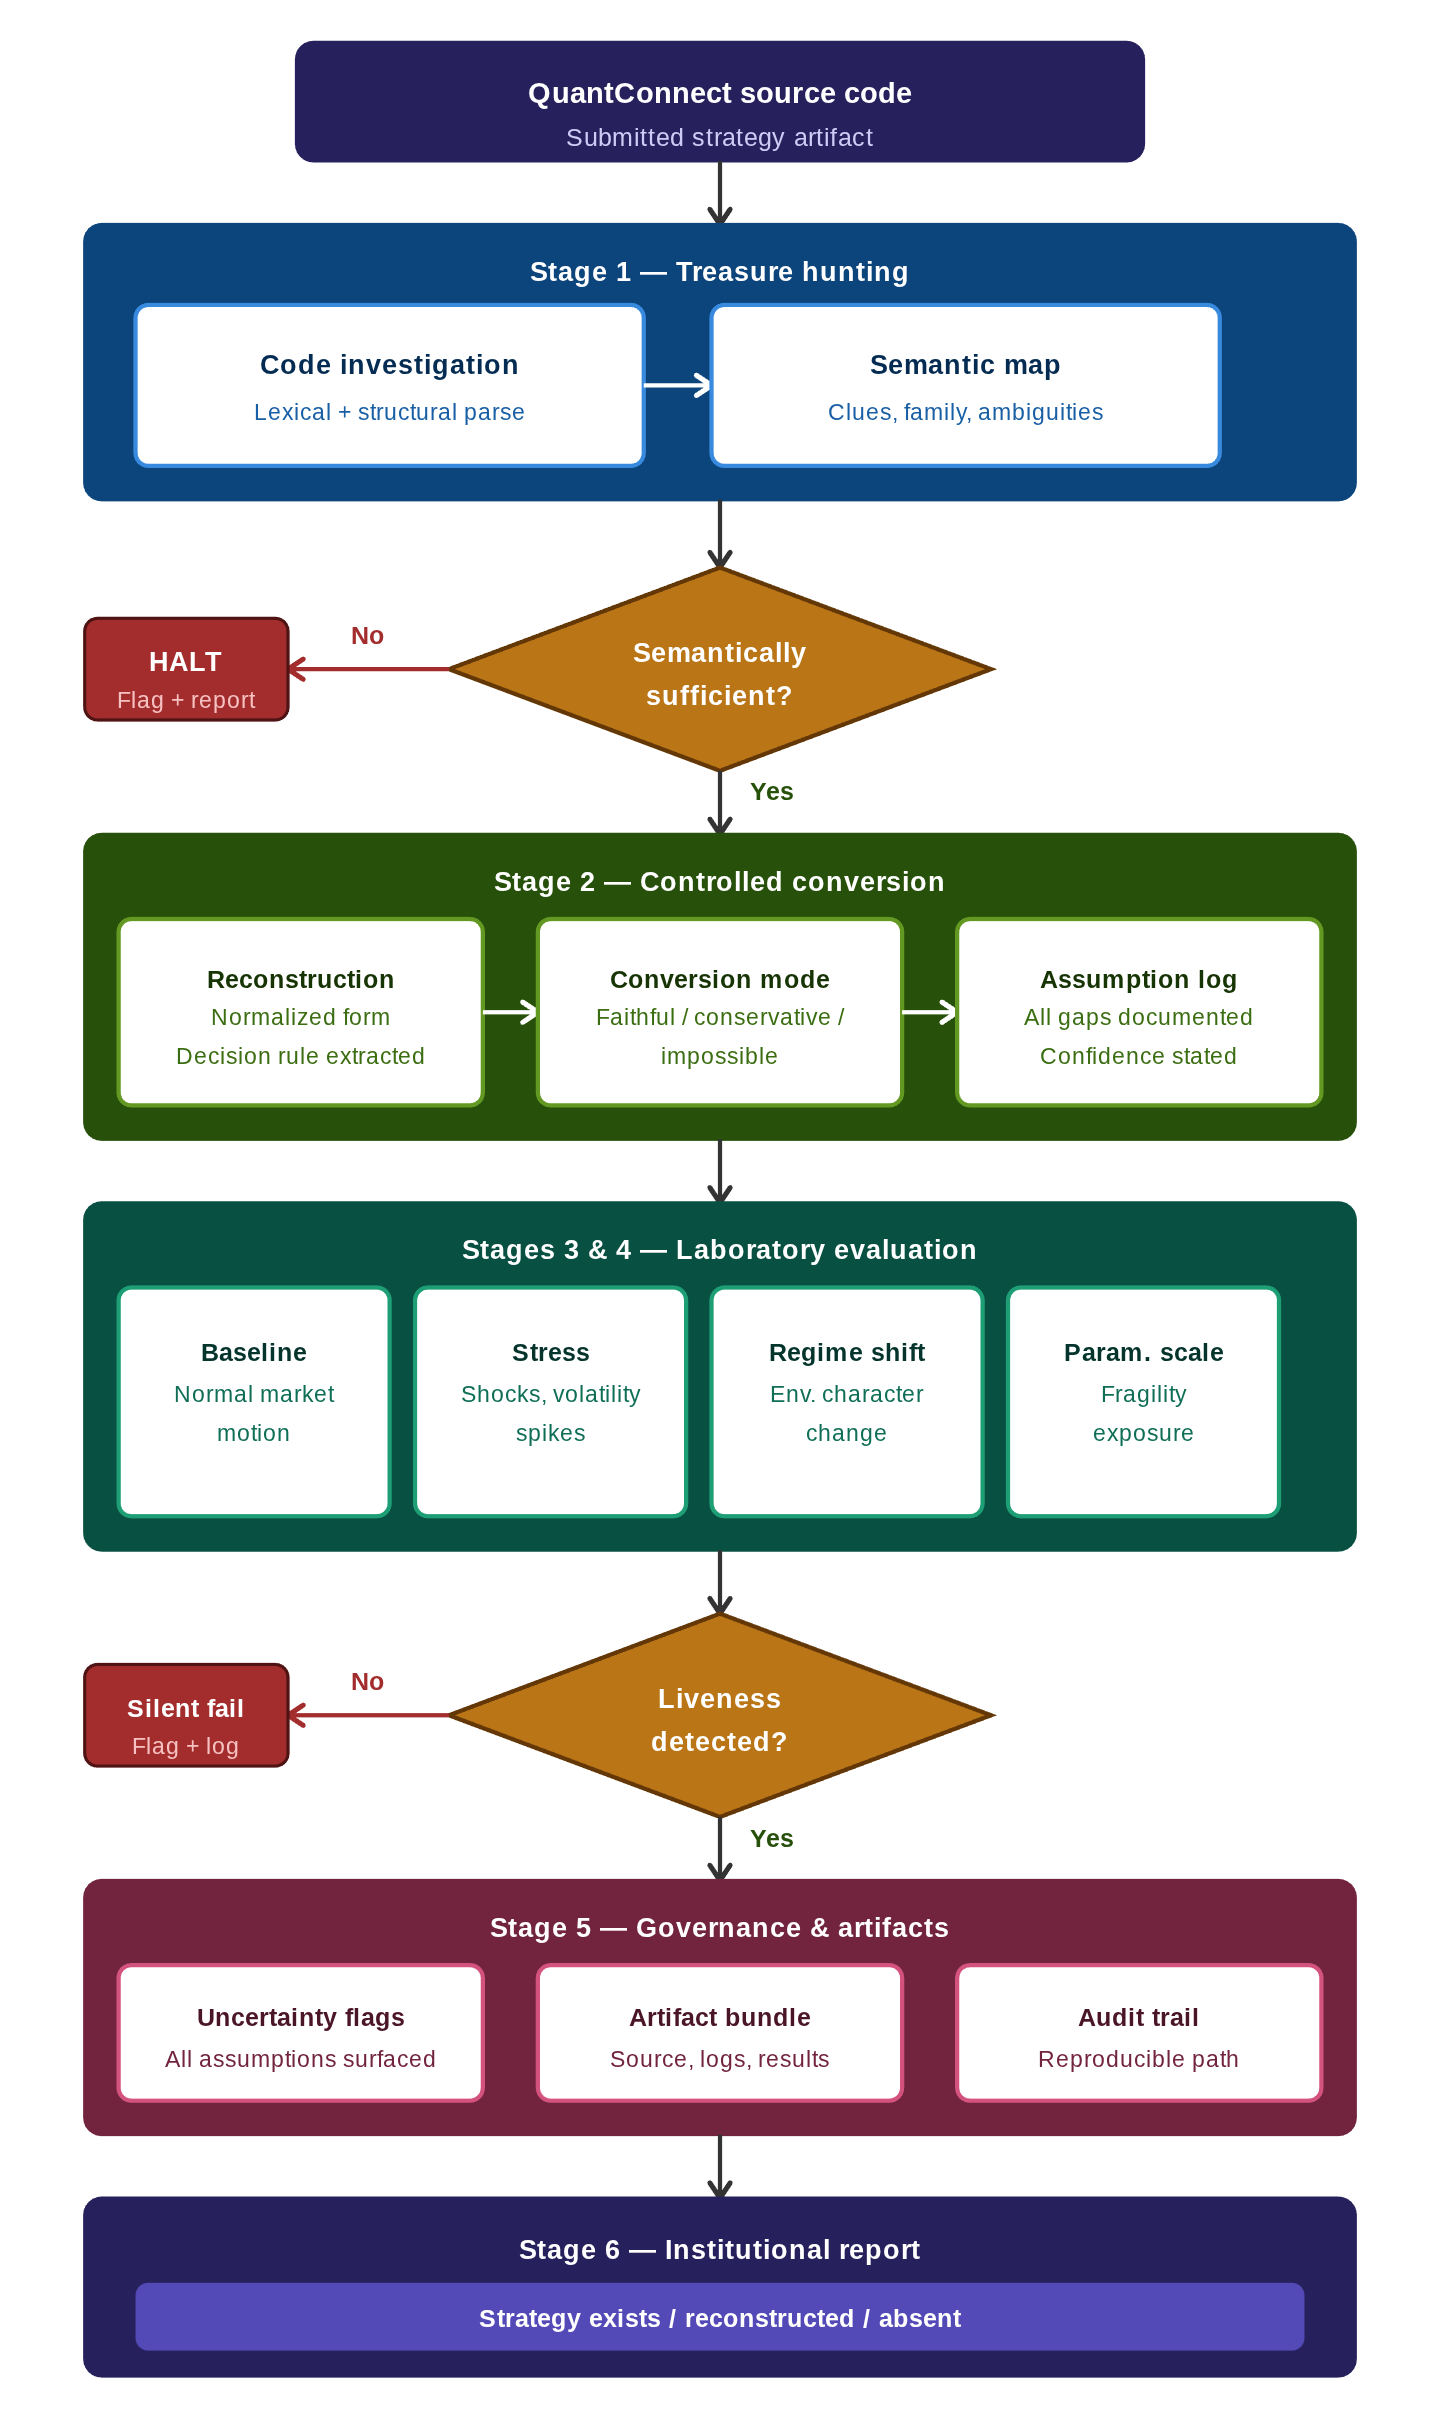

##2.LIBRARIES AND ENVIRONMENT

###2.1.OVERVIEW



Cell 2 establishes the notebook’s operating environment and creates the institutional scaffolding that makes the rest of the workflow reliable and reviewable. This cell is not where trading logic lives, but it is where the notebook defines its identity, its working folders, its run metadata, and its connection to the language model service. In practical terms, this means the cell prepares the notebook so that every later stage has a place to write its outputs and every run can be uniquely identified.

For financial professionals, this cell matters because it creates traceability. Rather than running a loose series of steps in an ad hoc fashion, the notebook begins by creating a structured workspace. It generates a run identifier, records the time, creates directories for logs, artifacts, plots, and generated code, and initializes helper functions that will be used repeatedly across the notebook. This is the beginning of the audit trail. If the notebook produces a result later on, this cell helps ensure there is a defined place where the evidence for that result is stored.

Another important function of this cell is connection management. The notebook needs to communicate with an external language model, and this cell establishes that capability in a controlled way. It checks whether the required credentials are available, whether the notebook is running in Colab, and whether the environment is ready to proceed. In institutional settings, this is important because failed or inconsistent setup is one of the most common reasons evaluation pipelines become unreliable. A strong evaluation workflow begins with a stable operational foundation.

Cell 2 also defines utility functions. These include functions for writing text files, writing structured JSON files, appending records to logs, hashing content, and timestamping actions. None of these are glamorous, but they are extremely important. In a governance-oriented workflow, clean file writing and content hashing are not peripheral conveniences. They are part of the control architecture. They make it possible to know what was submitted, what was generated, and whether outputs changed across runs.

Pedagogically, this cell teaches a useful lesson: before evaluating a strategy, one must first define the evaluation environment. Many professionals jump directly to the signal or the backtest. This cell reminds us that disciplined model review starts with infrastructure, identification, and reproducibility. Without that foundation, later results may be technically interesting but operationally weak.



###2.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 1
!pip -q install openai numpy matplotlib pydantic

In [ ]:
# CELL 2
import os
import re
import json
import math
import uuid
import zipfile
import hashlib
import traceback
import datetime as dt
import importlib.util
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from openai import OpenAI

try:
    from google.colab import userdata, files
    IN_COLAB = True
except Exception:
    userdata = None
    files = None
    IN_COLAB = False

UTC = dt.timezone.utc
RUN_ID = f"algo_eval_np_{dt.datetime.now(UTC).strftime('%Y%m%dT%H%M%SZ')}_{uuid.uuid4().hex[:8]}"
ROOT = Path("/content/algo_eval_no_pandas")
ARTIFACTS = ROOT / "artifacts"
LOGS = ARTIFACTS / "logs"
PLOTS = ARTIFACTS / "plots"
PACKS = ARTIFACTS / "packs"
CODE_DIR = ROOT / "generated_code"

for p in [ROOT, ARTIFACTS, LOGS, PLOTS, PACKS, CODE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

def utc_now_iso():
    return dt.datetime.now(UTC).isoformat()

def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def write_text(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

def write_json(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def append_jsonl(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

def extract_between(text: str, start_tag: str, end_tag: str) -> str:
    m = re.search(re.escape(start_tag) + r"(.*?)" + re.escape(end_tag), text, flags=re.DOTALL)
    return m.group(1).strip() if m else ""

def make_client():
    api_key = None
    if IN_COLAB and userdata is not None:
        try:
            api_key = userdata.get("OPENAI_API_KEY")
        except Exception:
            api_key = None
    if not api_key:
        api_key = os.environ.get("OPENAI_API_KEY", "")
    if not api_key:
        raise RuntimeError("OPENAI_API_KEY not found in Colab Secrets or environment.")
    return OpenAI(api_key=api_key)

CLIENT = make_client()
MODEL = os.environ.get("OPENAI_MODEL", "gpt-5")

manifest = {
    "run_id": RUN_ID,
    "created_at_utc": utc_now_iso(),
    "model": MODEL,
    "seed": SEED,
    "notebook_style": "strictly_no_pandas",
    "purpose": "QuantConnect strategy evaluation with LLM conversion, synthetic data, stress testing, regime-shift testing, and governance audit packs."
}
write_json(ARTIFACTS / "run_manifest.json", manifest)

print("RUN_ID:", RUN_ID)
print("ROOT:", ROOT)
print("MODEL:", MODEL)

RUN_ID: algo_eval_np_20260324T221914Z_65706a67
ROOT: /content/algo_eval_no_pandas
MODEL: gpt-5


##3.PASTE QUANTCONNECT CODE

###3.1.OVERVIEW

Cell 3 is where the notebook receives the source strategy. This is the intake stage. The user either pastes QuantConnect code directly into the notebook or uploads a file containing that code. Once received, the notebook records the source code as an input artifact and prepares the instructions that will later be sent to the language model for conversion. In other words, this cell defines what is being evaluated and how the conversion agent should think about its task.

For financial professionals, this is one of the most important cells because it marks the formal beginning of the evidence boundary. The notebook is no longer working in abstraction. It is now anchored to a specific strategy submission. The source code is recorded, hashed, and described in a compact input packet. This packet notes the origin of the code, its size, and its verification status. This is useful because it means the evaluation process is tied to a clearly documented input rather than a vague notion of what the strategy might be.

Another key role of this cell is instruction framing. The notebook prepares a structured prompt telling the language model how to convert the QuantConnect strategy into a pure Python strategy module. The instructions specify what the output must look like, what functions must be present, what constraints apply, and how ambiguity should be handled. This is a powerful architectural choice. Rather than letting the language model improvise, the notebook gives it a tightly bounded role. This reduces the risk of unstructured output and improves the interpretability of the conversion stage.

Cell 3 is also pedagogically helpful because it shows that language model prompting in professional workflows should behave more like an operating procedure than a casual conversation. The notebook does not merely ask for a translation. It defines an exact target format, exact expectations, and exact metadata requirements. For financial professionals, this is a good model for how large language models should be used in sensitive contexts: not as loose creative assistants, but as constrained contributors within a governed process.

In short, this cell turns an informal strategy submission into a formal evaluated object. That transformation is essential. Once the code has been recorded and the conversion instructions prepared, the rest of the notebook can proceed with a clear understanding of what it is reviewing and how the next stage should behave.



###3.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 3
# Paste QuantConnect code here, or upload a file when prompted.

QUANTCONNECT_CODE = r'''
#region imports
from AlgorithmImports import *
#endregion

class RetrospectiveYellowGreenAlligator(QCAlgorithm):

    def Initialize(self):
        self.SetStartDate(2012, 6, 1)
        self.SetEndDate(2025, 4, 1)
        self.SetCash(50000)
        self.ticker = "IVV"
        self.spy = self.AddEquity("SPY", Resolution.Daily).Symbol
        self._ticker = self.AddEquity(self.ticker, Resolution.Daily).Symbol
        self._numDays = 20

    def OnData(self, data):
        pass
'''

if IN_COLAB and files is not None:
    print("Optional upload: choose a .py or .txt QuantConnect file, or cancel to keep the pasted code.")
    try:
        uploaded = files.upload()
        if uploaded:
            first_name = next(iter(uploaded.keys()))
            QUANTCONNECT_CODE = uploaded[first_name].decode("utf-8", errors="ignore")
            print("Loaded uploaded file:", first_name)
    except Exception:
        pass

input_packet = {
    "run_id": RUN_ID,
    "received_at_utc": utc_now_iso(),
    "source_type": "QuantConnect",
    "source_sha256": sha256_text(QUANTCONNECT_CODE),
    "chars": len(QUANTCONNECT_CODE),
    "lines": len(QUANTCONNECT_CODE.splitlines()),
    "verification_status": "Not verified"
}

write_text(ARTIFACTS / "input_quantconnect_code.py", QUANTCONNECT_CODE)
write_json(ARTIFACTS / "input_packet.json", input_packet)

SYSTEM_CONVERTER = """
You are a QuantConnect-to-Python conversion engine for synthetic evaluation.

Your goal:
Convert the supplied QuantConnect strategy into a PURE PYTHON module that uses ONLY built-in Python plus numpy.

Output must be EXACTLY:

<<<BEGIN_METADATA_JSON>>>
{valid JSON}
<<<END_METADATA_JSON>>>
<<<BEGIN_PYTHON_CODE>>>
# python code here
<<<END_PYTHON_CODE>>>

Rules:
1. NO pandas.
2. The generated code must be self-contained and executable.
3. It must define:
   STRATEGY_METADATA = {...}
   DEFAULT_CONFIG = {...}
   def prepare_features(market, config):
       ...
   def generate_positions(features, config):
       ...
4. market is a dict with numpy arrays:
   market["open"], market["high"], market["low"], market["close"], market["volume"], market["t"]
5. prepare_features returns a dict of numpy arrays with equal length.
6. generate_positions returns a numpy array of shape (n,) with values in {-1,0,1}.
7. Use conservative assumptions when semantics are unclear.
8. Metadata JSON must contain:
   strategy_name, inferred_assets, timeframe, core_hypothesis, assumptions, unknowns, indicators,
   entry_logic_summary, exit_logic_summary, sizing_logic_summary, risk_controls_detected,
   conversion_warnings, confidence_0_to_1
9. No prose outside the sentinels.
"""

USER_CONVERTER = f"""
Convert this QuantConnect code into the required pure Python numpy-only strategy module.

SOURCE CODE:
{QUANTCONNECT_CODE}
"""

append_jsonl(LOGS / "prompts_log.jsonl", {
    "ts_utc": utc_now_iso(),
    "stage": "conversion_prompt",
    "model": MODEL,
    "system_sha256": sha256_text(SYSTEM_CONVERTER),
    "user_sha256": sha256_text(USER_CONVERTER),
    "source_sha256": sha256_text(QUANTCONNECT_CODE)
})

print("Source SHA256:", input_packet["source_sha256"])

Optional upload: choose a .py or .txt QuantConnect file, or cancel to keep the pasted code.


Source SHA256: c25b26876f024ff45adb4fc5fec4e2a42858819aa14507d5ab6d4c21388b85f5


##4.LLM CHAT

###4.1.OVERVIEW



Cell 4 performs the first major language-model-driven task in the notebook: it asks the model to convert the submitted QuantConnect strategy into a pure Python strategy representation and then records the result. This is the translation stage. It is where platform-specific code is transformed into a notebook-friendly structure that can later be tested on synthetic data.

For financial professionals, this cell is valuable because it turns an otherwise difficult technical bridge into a controlled process. QuantConnect strategies are embedded in a framework with its own conventions, methods, and execution assumptions. Those strategies cannot simply be dropped into a plain notebook and expected to run. Cell 4 solves that problem by using a language model as a conversion engine. However, it does so carefully. The notebook does not merely take whatever text the model returns. It looks for required markers, extracts structured metadata, extracts the generated Python code, saves both, and raises an error if the format is not respected.

This cell therefore reflects an important governance principle: unstructured model output should not be trusted automatically. The conversion result must arrive in a defined shape, and if it does not, the notebook stops. That is a healthy control. It reduces the chance that a malformed or incomplete response will silently contaminate later stages.

Another strength of this cell is that it preserves both the raw model response and the parsed outputs. This means reviewers can later compare what the model originally produced with what the notebook ultimately used. In financial settings, this matters because conversion itself can introduce risk. If the resulting Python code does not match the original strategy’s intent, the notebook needs enough evidence to make that discrepancy visible.

From a teaching standpoint, Cell 4 demonstrates a disciplined approach to automation. The language model is performing a complex task, but the notebook wraps that task in structure, validation, and storage. This is exactly the kind of pattern that financial professionals should become comfortable with: allowing machine assistance while still maintaining operational control and reviewability.



###4.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 4
def llm_chat(system_text: str, user_text: str) -> str:
    response = CLIENT.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "developer", "content": system_text},
            {"role": "user", "content": user_text},
        ],
    )
    text = response.choices[0].message.content
    append_jsonl(LOGS / "llm_raw_calls.jsonl", {
        "ts_utc": utc_now_iso(),
        "model": MODEL,
        "system_sha256": sha256_text(system_text),
        "user_sha256": sha256_text(user_text),
        "response_sha256": sha256_text(text),
        "response_chars": len(text)
    })
    return text

raw_conversion = llm_chat(SYSTEM_CONVERTER, USER_CONVERTER)

metadata_str = extract_between(raw_conversion, "<<<BEGIN_METADATA_JSON>>>", "<<<END_METADATA_JSON>>>")
python_code_str = extract_between(raw_conversion, "<<<BEGIN_PYTHON_CODE>>>", "<<<END_PYTHON_CODE>>>")

if not metadata_str or not python_code_str:
    raise RuntimeError("Missing required sentinels in conversion output.")

conversion_metadata = json.loads(metadata_str)
generated_py_path = CODE_DIR / "converted_strategy.py"

write_text(generated_py_path, python_code_str)
write_json(ARTIFACTS / "conversion_metadata.json", conversion_metadata)
write_text(ARTIFACTS / "conversion_raw_response.txt", raw_conversion)

print("Converted strategy saved to:", generated_py_path)
print(json.dumps(conversion_metadata, indent=2, ensure_ascii=False)[:4000])

Converted strategy saved to: /content/algo_eval_no_pandas/generated_code/converted_strategy.py
{
  "strategy_name": "RetrospectiveYellowGreenAlligator (No-Op)",
  "inferred_assets": [
    "SPY",
    "IVV"
  ],
  "timeframe": "Daily",
  "core_hypothesis": "No explicit trading hypothesis; holds cash and observes prices.",
  "assumptions": [
    "Single-market OHLCV arrays provided at a daily frequency",
    "No trades are executed (always flat)",
    "A 20-day moving average is computed as a placeholder feature to reflect the _numDays parameter"
  ],
  "unknowns": [
    "Actual entry/exit rules are unspecified",
    "Target asset for trading is unclear (both SPY and IVV were added)",
    "Risk management, position sizing, and transaction timing are undefined"
  ],
  "indicators": [
    "SMA(20) placeholder"
  ],
  "entry_logic_summary": "None. The original OnData contained no logic; no entries are generated.",
  "exit_logic_summary": "None. Positions remain flat at all times.",
  "sizing

##5.SYNTHETIC MARKET SCENARIOS

###5.1.OVERVIEW



Cell 5 creates the synthetic market scenarios that will be used to exercise the converted strategy. This is the notebook’s internal laboratory. Since the goal is not to access real market data at this stage, the notebook generates artificial price and volume paths representing different stylized conditions. These scenarios include a more ordinary baseline environment, a stressed environment, a regime-shift environment, and price-scaled variants. Each is meant to reveal something different about how the strategy behaves.

For financial professionals, this cell should be understood as a controlled testing ground rather than a source of market truth. Synthetic data does not prove investability or production readiness. What it does provide is a repeatable environment in which the notebook can ask preliminary behavioral questions. Does the strategy react at all? Does it behave differently under stress? Does it appear brittle when market conditions change? Does it remain coherent when price levels are scaled? Those are useful first-pass questions.

This cell is also important because it makes the evaluation process less dependent on external data access. That has practical value in notebook environments, demonstrations, and internal review settings where the goal is not yet live deployment but disciplined examination. By generating its own scenarios, the notebook can test strategy behavior consistently and cheaply.

The scenario manifest created here also contributes to governance. Each synthetic scenario is summarized and recorded, so a reviewer can later understand the shape of the inputs used during evaluation. This is a subtle but important point. If one is going to use artificial scenarios, one should document them. Otherwise the test environment itself becomes opaque.

Pedagogically, Cell 5 teaches an important lesson: preliminary strategy review does not always begin with a full production-grade historical dataset. Sometimes it begins with controlled synthetic environments designed to expose basic behavioral properties. This is especially useful when a strategy has just been converted or when reviewers first want to know whether the strategy is alive, responsive, and logically coherent before deeper validation efforts are undertaken.



###5.2.CODE AND IMPLEMENTTATION

In [ ]:
# CELL 5
def business_day_strings(n, start_date="2018-01-01"):
    start = dt.datetime.strptime(start_date, "%Y-%m-%d").date()
    out = []
    d = start
    while len(out) < n:
        if d.weekday() < 5:
            out.append(str(d))
        d += dt.timedelta(days=1)
    return out

def geometric_path(n, start=100.0, mu=0.08, sigma=0.18):
    dt_step = 1.0 / 252.0
    shocks = np.random.normal((mu - 0.5 * sigma * sigma) * dt_step, sigma * math.sqrt(dt_step), n)
    close = start * np.exp(np.cumsum(shocks))
    return close.astype(float)

def make_market_from_close(close, volume_level=1_000_000, start_date="2018-01-01"):
    n = len(close)
    open_ = np.empty(n, dtype=float)
    high = np.empty(n, dtype=float)
    low = np.empty(n, dtype=float)
    volume = np.empty(n, dtype=float)

    open_[0] = close[0]
    for i in range(1, n):
        open_[i] = close[i - 1] * (1.0 + np.random.normal(0.0, 0.002))

    spread = np.abs(np.random.normal(0.004, 0.002, n))
    high[:] = np.maximum(open_, close) * (1.0 + spread)
    low[:] = np.minimum(open_, close) * (1.0 - spread)
    volume[:] = np.maximum(1000, np.random.normal(volume_level, volume_level * 0.15, n))

    return {
        "t": np.array(business_day_strings(n, start_date=start_date), dtype=object),
        "open": open_,
        "high": high,
        "low": low,
        "close": close.astype(float),
        "volume": volume.astype(float)
    }

def scenario_baseline(n=1200):
    close = geometric_path(n=n, mu=0.10, sigma=0.16)
    return make_market_from_close(close, volume_level=1_000_000, start_date="2018-01-01")

def scenario_stress(n=1200):
    close = geometric_path(n=n, mu=0.03, sigma=0.28)
    shock_start = int(n * 0.55)
    shock_len = int(n * 0.08)
    close[shock_start:shock_start + shock_len] *= np.linspace(1.0, 0.72, shock_len)
    if shock_start + shock_len < n:
        close[shock_start + shock_len:] *= 0.82
    return make_market_from_close(close, volume_level=1_400_000, start_date="2018-01-01")

def scenario_regime_shift(n=1200):
    n1 = int(n * 0.40)
    n2 = int(n * 0.30)
    n3 = n - n1 - n2
    p1 = geometric_path(n1, start=100.0, mu=0.14, sigma=0.12)
    p2 = geometric_path(n2, start=float(p1[-1]), mu=-0.10, sigma=0.32)
    p3 = geometric_path(n3, start=float(p2[-1]), mu=0.05, sigma=0.18)
    close = np.concatenate([p1, p2, p3], axis=0)
    return make_market_from_close(close, volume_level=1_250_000, start_date="2018-01-01")

def scaled_market(market, scale):
    return {
        "t": market["t"].copy(),
        "open": market["open"] * scale,
        "high": market["high"] * scale,
        "low": market["low"] * scale,
        "close": market["close"] * scale,
        "volume": market["volume"].copy()
    }

SCENARIOS = {
    "baseline": scenario_baseline(),
    "stress": scenario_stress(),
    "regime_shift": scenario_regime_shift(),
    "price_scale_0_85": scaled_market(scenario_baseline(), 0.85),
    "price_scale_1_15": scaled_market(scenario_baseline(), 1.15)
}

scenario_manifest = {}
for name, market in SCENARIOS.items():
    scenario_manifest[name] = {
        "rows": int(len(market["close"])),
        "start": str(market["t"][0]),
        "end": str(market["t"][-1]),
        "close_start": float(market["close"][0]),
        "close_end": float(market["close"][-1]),
    }

write_json(ARTIFACTS / "synthetic_scenarios_manifest.json", scenario_manifest)
print("Scenarios:", list(SCENARIOS.keys()))

Scenarios: ['baseline', 'stress', 'regime_shift', 'price_scale_0_85', 'price_scale_1_15']


##6.BACKTESTING MODULES

###6.1.OVERVIEW



Cell 6 prepares the converted strategy for execution and defines the notebook’s internal backtesting engine. This is the bridge between translated strategy logic and measurable outputs. The cell loads the generated Python module, checks that the required strategy functions exist, and defines how the notebook will calculate returns, equity curves, trade counts, exposure, and other simple performance measures.

For financial professionals, this cell is where abstract strategy logic becomes observable behavior. Up to this point, the notebook has only received code and translated it. Cell 6 creates the mechanism that will actually test what the strategy does when exposed to market scenarios. It is therefore the beginning of operational evaluation, even if in a simplified synthetic environment.

The backtesting logic here is intentionally modest. It is not trying to recreate a full institutional trading simulator with complex execution assumptions, realistic slippage, and market microstructure detail. Instead, it provides a clear and interpretable framework for examining whether the strategy takes positions, how often it changes those positions, how its equity evolves, and how it compares with a simple benchmark. That simplicity is helpful pedagogically. It keeps the review process transparent and easier to explain to a non-technical audience.

Another important feature of this cell is its insistence on interface discipline. The converted strategy must provide specific functions and return outputs of the expected shape. If it does not, the notebook records the problem. This is not merely technical housekeeping. It reflects a broader control mindset. Strategies must fit the evaluation architecture, not the other way around. A disciplined workflow depends on predictable interfaces.

Cell 6 therefore serves two audiences at once. For technical users, it provides the evaluation mechanism. For governance-oriented users, it provides the assurance that the notebook is not simply accepting arbitrary code and improvising around it. It is applying a defined structure and measuring the result in a consistent way.



###6.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 6
def load_module_from_path(module_name: str, path: Path):
    spec = importlib.util.spec_from_file_location(module_name, str(path))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

def backtest_long_short(market, positions, fee_bps=5.0):
    close = np.asarray(market["close"], dtype=float)
    n = len(close)

    pos = np.asarray(positions, dtype=float).reshape(-1)
    if len(pos) != n:
        raise ValueError(f"Position length {len(pos)} does not match market length {n}.")
    pos = np.clip(np.round(pos), -1, 1)

    ret = np.zeros(n, dtype=float)
    ret[1:] = close[1:] / close[:-1] - 1.0

    turnover = np.zeros(n, dtype=float)
    turnover[0] = abs(pos[0])
    turnover[1:] = np.abs(pos[1:] - pos[:-1])

    cost = turnover * (fee_bps / 10000.0)

    lag_pos = np.zeros(n, dtype=float)
    lag_pos[1:] = pos[:-1]

    strategy_ret = lag_pos * ret - cost
    benchmark_ret = ret.copy()

    equity = np.cumprod(1.0 + strategy_ret)
    benchmark = np.cumprod(1.0 + benchmark_ret)

    mean_ret = float(np.mean(strategy_ret))
    std_ret = float(np.std(strategy_ret))
    ann_vol = float(std_ret * np.sqrt(252.0))
    sharpe = float((mean_ret / (std_ret + 1e-12)) * np.sqrt(252.0))

    downside = strategy_ret[strategy_ret < 0]
    downside_std = float(np.std(downside)) if len(downside) > 0 else 0.0
    sortino = float((mean_ret / (downside_std + 1e-12)) * np.sqrt(252.0)) if len(downside) > 0 else 0.0

    running_max = np.maximum.accumulate(equity)
    drawdown = equity / (running_max + 1e-12) - 1.0
    max_dd = float(np.min(drawdown))

    hit_rate = float(np.mean(strategy_ret > 0))
    avg_abs_exposure = float(np.mean(np.abs(pos)))
    trade_count = int(np.sum(np.abs(np.diff(pos)) > 0))

    metrics = {
        "total_return": float(equity[-1] - 1.0),
        "benchmark_return": float(benchmark[-1] - 1.0),
        "annualized_volatility": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_dd,
        "hit_rate": hit_rate,
        "average_abs_exposure": avg_abs_exposure,
        "trade_count": trade_count,
        "final_equity": float(equity[-1]),
        "final_benchmark": float(benchmark[-1])
    }

    curves = {
        "t": market["t"],
        "equity": equity,
        "benchmark": benchmark,
        "position": pos,
        "strategy_ret": strategy_ret,
        "benchmark_ret": benchmark_ret,
        "drawdown": drawdown
    }
    return curves, metrics

strategy_module = None
module_load_error = None

try:
    strategy_module = load_module_from_path("converted_strategy", generated_py_path)
    assert hasattr(strategy_module, "prepare_features")
    assert hasattr(strategy_module, "generate_positions")
except Exception:
    module_load_error = traceback.format_exc()

write_text(LOGS / "module_load_error.txt", module_load_error or "NO_ERROR")
print("Module loaded:", module_load_error is None)

Module loaded: True


##7.REPAIR STRATEGY CODE

###7.1.OVERVIEW



Cell 7 is the execution and repair stage. If the converted strategy cannot be loaded properly, this cell asks the language model to attempt a repair. If the strategy can be loaded, the cell runs it across all synthetic scenarios, collects the results, and generates the main scenario performance outputs. It also saves equity plots for later review.

For financial professionals, this cell demonstrates a useful but delicate idea: automation can be used not only to generate outputs but also to recover from certain classes of failure. If the conversion stage produces code that is close to usable but contains import or structural issues, the notebook does not immediately give up. Instead, it initiates a bounded repair procedure. This is powerful because it reduces friction in practical workflows. At the same time, the repair is controlled and logged, which helps preserve auditability.

Once the strategy is executable, this cell becomes the operational core of the notebook. It applies the converted strategy to each synthetic market scenario, computes the scenario results, and stores them in a structured form. This is where the notebook begins to reveal whether the strategy is active, inert, coherent, fragile, or obviously broken.

The equity plots produced here are also useful communication tools. Financial professionals often understand a process much more quickly when they can see the path of strategy equity relative to a benchmark. Even in a synthetic environment, the visual comparison helps communicate whether the strategy is doing something meaningful or merely drifting alongside, or below, a simple alternative.

Pedagogically, Cell 7 teaches that a robust evaluation system should be prepared for imperfect intermediate outputs. Conversion may not always work cleanly on the first pass. A good workflow anticipates that and responds in a structured way. At the same time, it does not hide the fact that repairs occurred. That balance between practicality and transparency is one of the most valuable lessons in the notebook.



###7.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 7
def repair_strategy_code(original_qc_code: str, broken_python_code: str, error_text: str) -> str:
    repair_system = """
You repair pure Python strategy modules.

Output must be EXACTLY:
<<<BEGIN_PYTHON_CODE>>>
# fixed code
<<<END_PYTHON_CODE>>>

Rules:
1. NO pandas.
2. Keep only built-in Python plus numpy.
3. Preserve:
   STRATEGY_METADATA
   DEFAULT_CONFIG
   prepare_features(market, config)
   generate_positions(features, config)
4. market is a dict of numpy arrays.
5. generate_positions must return a numpy array of shape (n,) with values in {-1,0,1}.
"""
    repair_user = f"""
Original QuantConnect code:
{original_qc_code}

Broken generated Python:
{broken_python_code}

Error:
{error_text}
"""
    repaired = llm_chat(repair_system, repair_user)
    return extract_between(repaired, "<<<BEGIN_PYTHON_CODE>>>", "<<<END_PYTHON_CODE>>>")

if module_load_error is not None:
    fixed_code = repair_strategy_code(QUANTCONNECT_CODE, python_code_str, module_load_error)
    if not fixed_code:
        raise RuntimeError("Repair failed: no corrected code returned.")
    write_text(generated_py_path, fixed_code)
    python_code_str = fixed_code
    strategy_module = load_module_from_path("converted_strategy_repaired", generated_py_path)

all_results = {}
all_curves = {}

for scenario_name, market in SCENARIOS.items():
    try:
        config = getattr(strategy_module, "DEFAULT_CONFIG", {})
        features = strategy_module.prepare_features(market, config)
        positions = strategy_module.generate_positions(features, config)
        curves, metrics = backtest_long_short(market, positions)
        all_results[scenario_name] = {
            "status": "ok",
            "metrics": metrics,
            "rows": int(len(market["close"]))
        }
        all_curves[scenario_name] = curves
    except Exception:
        all_results[scenario_name] = {
            "status": "error",
            "error": traceback.format_exc()
        }

write_json(ARTIFACTS / "scenario_results.json", all_results)

for scenario_name, curves in all_curves.items():
    plt.figure(figsize=(10, 4))
    plt.plot(curves["equity"], label="Strategy")
    plt.plot(curves["benchmark"], label="Benchmark")
    plt.title(f"Equity Curve: {scenario_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS / f"equity_{scenario_name}.png", dpi=160)
    plt.close()

print(json.dumps(all_results, indent=2)[:5000])

{
  "baseline": {
    "status": "ok",
    "metrics": {
      "total_return": 0.0,
      "benchmark_return": 1.3967491611896588,
      "annualized_volatility": 0.0,
      "sharpe": 0.0,
      "sortino": 0.0,
      "max_drawdown": -1.000088900582341e-12,
      "hit_rate": 0.0,
      "average_abs_exposure": 0.0,
      "trade_count": 0,
      "final_equity": 1.0,
      "final_benchmark": 2.3967491611896588
    },
    "rows": 1200
  },
  "stress": {
    "status": "ok",
    "metrics": {
      "total_return": 0.0,
      "benchmark_return": -0.6186078526743326,
      "annualized_volatility": 0.0,
      "sharpe": 0.0,
      "sortino": 0.0,
      "max_drawdown": -1.000088900582341e-12,
      "hit_rate": 0.0,
      "average_abs_exposure": 0.0,
      "trade_count": 0,
      "final_equity": 1.0,
      "final_benchmark": 0.38139214732566745
    },
    "rows": 1200
  },
  "regime_shift": {
    "status": "ok",
    "metrics": {
      "total_return": 0.0,
      "benchmark_return": -0.2122940132105955,
 

##8.GOVERNANCE SIGNALS

###8.1.OVERVIEW



Cell 8 converts scenario performance into governance signals. This is where the notebook steps beyond pure backtest output and begins to ask control-oriented questions. It examines the results for issues such as low conversion confidence, unresolved semantic unknowns, failed executions, implausible performance, excessive drawdowns, or inactive strategies. It then records those findings in a risk log and assembles a governance audit pack.

For financial professionals, this cell is essential because it reframes evaluation as more than performance measurement. A strategy may generate returns, but if those returns rest on a dubious conversion, unresolved ambiguity, or suspiciously clean synthetic behavior, the notebook should not treat the outcome as reassuring. Cell 8 formalizes that principle. It looks for red flags and classifies them.

This stage is particularly valuable for institutional review because it makes the governance posture explicit. Rather than leaving concerns implicit in someone’s intuition, the notebook records them in structured form. This enables consistency across runs and makes the final assessment easier to explain. If a strategy is flagged as inactive, low-confidence, or execution-failed, those issues become part of the permanent record of the run.

Another strength of this cell is that it produces summary outputs that are easier for non-technical reviewers to interpret. Rather than reading raw arrays or digging through intermediate objects, a reviewer can inspect a scenario summary and a concise set of flags. This lowers the barrier to cross-functional collaboration. A risk manager, governance officer, or senior financial decision-maker can engage with the outputs more directly.

Cell 8 therefore plays a major role in turning a technical experiment into an institutional artifact. It translates raw behavior into review language, and that makes the overall workflow much more relevant for financial practice.



###8.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 8
def derive_governance_flags(conversion_meta, results):
    flags = []

    conf = float(conversion_meta.get("confidence_0_to_1", 0.0) or 0.0)
    if conf < 0.60:
        flags.append({
            "severity": "high",
            "category": "conversion_confidence",
            "message": f"Low conversion confidence: {conf:.2f}"
        })

    unknowns = conversion_meta.get("unknowns", [])
    if isinstance(unknowns, list) and len(unknowns) > 0:
        flags.append({
            "severity": "medium",
            "category": "unknowns",
            "message": f"{len(unknowns)} unresolved semantic unknowns detected."
        })

    failed = [k for k, v in results.items() if v.get("status") != "ok"]
    if failed:
        flags.append({
            "severity": "high",
            "category": "execution_failure",
            "message": "Scenario execution failed for: " + ", ".join(failed)
        })

    ok_metrics = [v["metrics"] for v in results.values() if v.get("status") == "ok"]
    if ok_metrics:
        sharpes = [float(m["sharpe"]) for m in ok_metrics]
        maxdds = [float(m["max_drawdown"]) for m in ok_metrics]
        trades = [int(m["trade_count"]) for m in ok_metrics]

        if max(sharpes) > 4.0:
            flags.append({
                "severity": "medium",
                "category": "performance_plausibility",
                "message": "Synthetic Sharpe exceeded 4.0 in at least one scenario."
            })

        if min(trades) == 0:
            flags.append({
                "severity": "high",
                "category": "inactive_strategy",
                "message": "At least one scenario produced zero trade changes."
            })

        if min(maxdds) < -0.40:
            flags.append({
                "severity": "medium",
                "category": "drawdown",
                "message": "At least one scenario exceeded -40% drawdown."
            })

    return flags

governance_flags = derive_governance_flags(conversion_metadata, all_results)

summary_rows = []
for scenario_name, result in all_results.items():
    row = {"scenario": scenario_name, "status": result["status"]}
    if result["status"] == "ok":
        row.update(result["metrics"])
    else:
        row["error_head"] = result["error"].splitlines()[-1] if result.get("error") else "Unknown error"
    summary_rows.append(row)

audit_pack = {
    "run_id": RUN_ID,
    "generated_at_utc": utc_now_iso(),
    "verification_status": "Not verified",
    "input_packet": input_packet,
    "conversion_metadata": conversion_metadata,
    "scenario_results": all_results,
    "governance_flags": governance_flags,
    "decision_policy": {
        "approve_only_if": [
            "No high-severity execution failures",
            "Conversion confidence >= 0.60",
            "Synthetic scenario evidence is coherent"
        ],
        "otherwise": "HUMAN_REVIEW"
    }
}

write_json(PACKS / "governance_audit_pack.json", audit_pack)
write_json(ARTIFACTS / "risk_log.json", {"run_id": RUN_ID, "flags": governance_flags})
write_json(ARTIFACTS / "scenario_summary.json", summary_rows)

print(json.dumps(summary_rows, indent=2)[:5000])
print(json.dumps(governance_flags, indent=2))

[
  {
    "scenario": "baseline",
    "status": "ok",
    "total_return": 0.0,
    "benchmark_return": 1.3967491611896588,
    "annualized_volatility": 0.0,
    "sharpe": 0.0,
    "sortino": 0.0,
    "max_drawdown": -1.000088900582341e-12,
    "hit_rate": 0.0,
    "average_abs_exposure": 0.0,
    "trade_count": 0,
    "final_equity": 1.0,
    "final_benchmark": 2.3967491611896588
  },
  {
    "scenario": "stress",
    "status": "ok",
    "total_return": 0.0,
    "benchmark_return": -0.6186078526743326,
    "annualized_volatility": 0.0,
    "sharpe": 0.0,
    "sortino": 0.0,
    "max_drawdown": -1.000088900582341e-12,
    "hit_rate": 0.0,
    "average_abs_exposure": 0.0,
    "trade_count": 0,
    "final_equity": 1.0,
    "final_benchmark": 0.38139214732566745
  },
  {
    "scenario": "regime_shift",
    "status": "ok",
    "total_return": 0.0,
    "benchmark_return": -0.2122940132105955,
    "annualized_volatility": 0.0,
    "sharpe": 0.0,
    "sortino": 0.0,
    "max_drawdown": -1.0000

##9.EVALUATION

###9.1.OVERVIEW



Cell 9 asks the evaluation agent to synthesize the evidence and produce a committee-style judgment. This is the report-writing stage. The notebook provides the model with conversion metadata, scenario results, governance flags, and the verification status, and the model returns both a structured evaluation record and a narrative committee report.

For financial professionals, this cell is especially useful because it transforms raw evidence into decision-ready language. Many review processes struggle not because evidence is missing, but because evidence is not communicated clearly. A senior reviewer may not want to inspect conversion metadata, benchmark returns, or trade counts line by line. Instead, they want a concise but serious assessment: what happened, what the main issues are, what risks remain, and what should happen next. Cell 9 produces exactly that.

The structured part of the output is important because it preserves machine-readability and comparability. The narrative part is equally important because real committees and reviewers think in prose. They need a coherent explanation, not only a set of fields. This cell therefore combines both: structured outputs for systems and narrative outputs for people.

From a governance standpoint, this is also where the notebook formalizes restraint. The evaluation agent is instructed not to confuse synthetic results with real-world validation. It is told to recommend rejection or human review when failures are material. It is told to respect ambiguity rather than overstating confidence. These are exactly the right habits for language models in financial settings. Good reporting is not about sounding impressive. It is about making justified claims and preserving appropriate caution.

Pedagogically, Cell 9 shows how language models can be used responsibly in finance. They are not replacing human judgment, but they are helping package evidence into a consistent review memorandum. That makes them more operationally useful and easier to govern.



###9.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 9
EVALUATION_SYSTEM = """
You are the ALGO EVALUATION committee agent.

You will receive:
1. Conversion metadata.
2. Synthetic scenario results.
3. Governance flags.

Return EXACTLY:
<<<BEGIN_EVAL_JSON>>>
{valid JSON}
<<<END_EVAL_JSON>>>
<<<BEGIN_COMMITTEE_REPORT>>>
plain text report
<<<END_COMMITTEE_REPORT>>>

The JSON must contain:
final_recommendation, rationale, key_strengths, key_weaknesses, model_risk_findings,
regime_sensitivity_findings, stress_test_findings, governance_findings, next_actions, confidence_0_to_1

Rules:
- Treat all evidence as synthetic.
- Never claim real-market validation.
- If there are material failures, recommend REJECT or HUMAN_REVIEW.
- If semantics remain uncertain but evidence is still useful, prefer HUMAN_REVIEW.
"""

EVALUATION_USER = json.dumps({
    "conversion_metadata": conversion_metadata,
    "scenario_results": all_results,
    "governance_flags": governance_flags,
    "verification_status": "Not verified"
}, indent=2)

raw_eval = llm_chat(EVALUATION_SYSTEM, EVALUATION_USER)

eval_json_str = extract_between(raw_eval, "<<<BEGIN_EVAL_JSON>>>", "<<<END_EVAL_JSON>>>")
committee_report = extract_between(raw_eval, "<<<BEGIN_COMMITTEE_REPORT>>>", "<<<END_COMMITTEE_REPORT>>>")

if not eval_json_str or not committee_report:
    raise RuntimeError("Missing required sentinels in committee evaluation output.")

evaluation_json = json.loads(eval_json_str)

write_json(ARTIFACTS / "evaluation.json", evaluation_json)
write_text(ARTIFACTS / "committee_report.txt", committee_report)
write_text(ARTIFACTS / "evaluation_raw_response.txt", raw_eval)

print(json.dumps(evaluation_json, indent=2, ensure_ascii=False))
print("\n===== COMMITTEE REPORT PREVIEW =====\n")
print(committee_report[:4000])

{
  "final_recommendation": "HUMAN_REVIEW",
  "rationale": "The converted strategy is an intentional no-op: it never takes positions, generates zero trades across all scenarios, and lacks any defined hypothesis, entry/exit logic, sizing, or risk controls. Conversion confidence is low (0.18), multiple semantic unknowns remain unresolved, and governance flags indicate an inactive strategy. While technically safe (cash-only), it is not a deployable trading system. Human clarification and redesign are required before reconsideration.",
  "key_strengths": [
    "Capital preservation via zero exposure; deterministic, reproducible behavior.",
    "Invariant outcomes across regimes and price scaling demonstrate stable plumbing.",
    "Simple, transparent implementation reduces operational complexity.",
    "Placeholder SMA(20) indicates basic data pipeline and feature computation are functioning."
  ],
  "key_weaknesses": [
    "No trading hypothesis or alpha; entry/exit logic absent; zero tra

##10.FINAL RECOMMENDATION

###10.1.OVERVIEW



Cell 10 closes the loop. It records the final state of the run, bundles the artifacts into a portable package, prints the final recommendation, and makes the audit bundle available for download. This is the notebook’s completion and handoff stage.

For financial professionals, this cell is where the evaluation becomes operationally useful. Without a final bundling step, the notebook would merely be a sequence of actions. With this step, it becomes a deliverable. The run has a final state, a recommendation, a stored committee report, and a packaged archive of artifacts that can be reviewed, shared, or retained. This is especially helpful in professional settings where evidence must move from a technical analyst to a manager, a model reviewer, or a governance committee.

The creation of a bundled archive is more important than it may first appear. In many organizations, one of the persistent weaknesses of notebook-based workflows is that evidence remains scattered across cells, outputs, and local folders. Cell 10 solves that problem by creating a clear endpoint. The notebook is not merely run; it concludes in a structured way.

This cell also reinforces the idea that evaluation is a documented event. A strategy review is not just something a person looked at informally. It is something that generated a final state with identified artifacts. That is a healthier institutional pattern, particularly when one expects repeated reviews over time or comparisons across multiple strategies.

Pedagogically, Cell 10 reminds us that the end of an analytical process matters just as much as the beginning. A strong workflow should not simply stop when the main analysis is done. It should record what happened, summarize the outcome, and package the evidence. That discipline turns a notebook from a personal experiment into a professional review instrument.



###10.2.CODE AND IMPLEMENTATION

In [ ]:
# CELL 10
final_state = {
    "run_id": RUN_ID,
    "completed_at_utc": utc_now_iso(),
    "verification_status": "Not verified",
    "final_recommendation": evaluation_json.get("final_recommendation", "HUMAN_REVIEW"),
    "committee_confidence_0_to_1": evaluation_json.get("confidence_0_to_1"),
    "artifacts": sorted([str(p.relative_to(ROOT)) for p in ROOT.rglob("*") if p.is_file()])
}
write_json(ARTIFACTS / "final_state.json", final_state)

zip_path = ROOT / f"{RUN_ID}_audit_bundle.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in ROOT.rglob("*"):
        if p.is_file() and p != zip_path:
            zf.write(p, arcname=str(p.relative_to(ROOT)))

print("FINAL RECOMMENDATION:", final_state["final_recommendation"])
print("ZIP BUNDLE:", zip_path)

with open(ARTIFACTS / "committee_report.txt", "r", encoding="utf-8") as f:
    print("\n===== FULL COMMITTEE REPORT =====\n")
    print(f.read())

if IN_COLAB and files is not None:
    try:
        files.download(str(zip_path))
    except Exception:
        pass

FINAL RECOMMENDATION: HUMAN_REVIEW
ZIP BUNDLE: /content/algo_eval_no_pandas/algo_eval_np_20260324T221914Z_65706a67_audit_bundle.zip

===== FULL COMMITTEE REPORT =====

Summary
The submitted conversion is a non-operational placeholder. It never takes positions, yields zero trades and zero return across all scenarios, and lacks a defined hypothesis, trade rules, sizing, and risk management. Governance flags include low conversion confidence (0.18), unresolved semantic unknowns, and an inactive strategy alert. Recommendation: HUMAN_REVIEW. Not approved for deployment.

Evidence from synthetic scenarios
- Baseline, stress, regime-shift, and price-scaled runs all show total_return = 0.0, trade_count = 0, average_abs_exposure = 0.0, and annualized_volatility = 0.0.
- Benchmarks vary widely, confirming the strategy’s invariance to market conditions and price scaling.
- Max drawdown near zero results from no exposure; not indicative of actual risk management.

Material issues
- No hypothesis; 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##11.CONCLUSIONS



The notebook described here represents much more than a technical convenience for converting and testing QuantConnect code. It is an example of how financial professionals can begin building governed workflows around strategy evaluation in a world increasingly shaped by automation, interoperability problems, and language-model-assisted tooling. Its real value lies not in any individual line of logic, nor in any one synthetic scenario, but in the discipline of the process it enforces. It receives code, records it, translates it under constraints, tests it in controlled environments, generates governance signals, and produces a reviewable package of evidence. That sequence is precisely what makes the notebook institutionally meaningful.

One of the strongest messages of this workflow is that strategy evaluation should not be confused with strategy celebration. Too often, evaluation pipelines are designed to produce attractive charts, favorable narratives, or quick summaries of supposed performance. This notebook takes a different stance. It is willing to conclude that a strategy is inactive, semantically incomplete, low-confidence, or unsuitable for normal evaluation. That willingness is a sign of maturity. In professional finance, especially where capital, reputation, and governance are involved, a system that can say “this is not ready” is often more valuable than one that always finds something flattering to report.

The notebook also helps financial professionals understand an important operational reality: translation between environments is not a neutral act. A QuantConnect strategy and a pure Python evaluation module are not the same thing. Moving from one to the other introduces interpretation risk. Missing logic may be inferred. Framework assumptions may be simplified. Ambiguities may be filled with conservative defaults. By surfacing conversion metadata and confidence levels, the notebook acknowledges that problem rather than hiding it. That honesty is central to trustworthy evaluation. The notebook is not pretending that the conversion process is perfect. It is documenting the limits of what the conversion can claim.

This matters because the modern financial technology landscape is increasingly fragmented. Strategies are written in one environment, tested in another, reported in a third, and governed by people who may not use any of those tools directly. A notebook like this creates a bridge across that fragmentation. It enables a strategy written in one system to be brought into a controlled evaluation context without losing sight of governance. It also makes the process legible to non-specialists. That is important. The future of financial model review will not belong exclusively to coders or exclusively to governance officers. It will belong to workflows that make the relevant evidence visible and interpretable to both.

Another lesson from this notebook is the importance of liveness. In many technical workflows, a silent failure is more dangerous than a loud one. A strategy that crashes can at least be identified as broken. A strategy that runs cleanly while doing nothing can be mistakenly treated as valid. The notebook’s ability to expose zero-trade, zero-exposure outcomes is therefore not a weakness. It is a control advantage. It forces a distinction between a functioning but poor strategy and a non-strategy masquerading as one. For financial professionals, that is not a minor nuance. It is a critical governance distinction. A weak investment idea can still be examined, improved, or rejected on its merits. An empty strategy first needs to be recognized as empty.

The synthetic scenario framework also deserves to be understood properly. It is not designed to convince a committee that the strategy has alpha. It is designed to ask simpler but still important questions. Does the strategy react? Does it survive a change in conditions? Does it remain sensible under stress? Does it behave consistently when price levels change? These are preliminary questions, but they matter. In a world where evaluation resources are limited and strategies may arrive in incomplete forms, synthetic testing can be an efficient early-stage screening tool. It is especially useful when combined with governance metadata, because it helps prevent overinterpretation of what the synthetic results actually mean.

The committee-style evaluation stage is another important contribution. In practice, evidence only becomes useful when it can be communicated. Financial professionals do not merely need files; they need judgments, caveats, and next actions. By producing both structured evaluation records and narrative reports, the notebook serves both machine workflows and human decision-making. That duality is increasingly important in finance. Systems need structured data for comparison, automation, and aggregation, but people need prose for interpretation, escalation, and accountability. This notebook recognizes that both forms are necessary.

From an educational perspective, the notebook offers a practical model for how large language models can be used without surrendering discipline. The model is not treated as an all-knowing evaluator of investment merit. Instead, it is placed into specific bounded roles: conversion, repair, and committee-style synthesis. Each role is surrounded by controls. Inputs are structured. outputs are expected in precise formats. Results are logged. Failures are surfaced. This is a much healthier architecture than the more common pattern of asking a language model broad financial questions and then hoping for sensible answers. For financial professionals trying to understand how these tools can fit into institutional work, this notebook provides a concrete example of responsible use.

It is equally important to see where the notebook stops. It does not replace real historical validation. It does not simulate actual execution conditions in a production-grade way. It does not measure slippage realism, exchange interaction, borrow constraints, data quality risk, or infrastructure latency. It does not grant permission to deploy. These limits should not be seen as shortcomings in the usual sense. They are boundaries that protect the integrity of the process. In fact, one reason the notebook is useful is that it does not overclaim. It occupies an intermediate layer of analysis: more rigorous than an informal code reading, but more modest than a full institutional validation stack.

That intermediate layer may become increasingly valuable in the years ahead. As financial firms and independent professionals alike work with more externally authored code, more AI-assisted research processes, and more cross-platform strategy workflows, the need for structured pre-deployment review will grow. It will no longer be sufficient to say that code “runs” in one environment. Reviewers will want to know whether it was translated faithfully, whether it behaves coherently in controlled conditions, whether it reveals obvious governance concerns, and whether its limitations have been clearly documented. This notebook is a strong prototype of that kind of review framework.
